# Parameter Golf — Step 1.5: Baseline Recheck

Re-run key Step 1 experiments with the same fast settings as Step 2 (2000 iters, 5 shards, no torch.compile) to get a fair comparison baseline.

**Purpose:** Step 2 results looked worse than Step 1, but settings differed. This normalizes the comparison.

## 1. Install Dependencies

In [3]:
!pip install -q torch numpy tqdm huggingface-hub sentencepiece

## 2. Clone Repo & Download Data

In [4]:
import os

REPO_DIR = "/content/parameter-golf"

if not os.path.exists(REPO_DIR):
    !git clone https://github.com/openai/parameter-golf.git {REPO_DIR}

os.chdir(REPO_DIR)
print(f"Working directory: {os.getcwd()}")

Cloning into '/content/parameter-golf'...
remote: Enumerating objects: 426, done.
remote: Counting objects: 100% (2/2), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 426 (delta 0), reused 0 (delta 0), pack-reused 424 (from 2)
Receiving objects: 100% (426/426), 785.66 KiB | 2.59 MiB/s, done.
Resolving deltas: 100% (191/191), done.
Working directory: /content/parameter-golf


In [5]:
# Download training shards + validation + tokenizer
# 5 shards (~1GB) for fast directional experiments. Increase for final runs (max 80).
TRAIN_SHARDS = 5

!python data/cached_challenge_fineweb.py --train-shards {TRAIN_SHARDS}

manifest.json: 1.93kB [00:00, 5.73MB/s]
datasets/datasets/fineweb10B_sp1024/fine(…): 100% 124M/124M [00:01<00:00, 87.0MB/s]
datasets/datasets/fineweb10B_sp1024/fine(…): 100% 200M/200M [00:01<00:00, 142MB/s]
datasets/datasets/fineweb10B_sp1024/fine(…): 100% 200M/200M [00:01<00:00, 164MB/s]
datasets/datasets/fineweb10B_sp1024/fine(…): 100% 200M/200M [00:01<00:00, 142MB/s]
datasets/datasets/fineweb10B_sp1024/fine(…): 100% 200M/200M [00:01<00:00, 165MB/s]
datasets/datasets/fineweb10B_sp1024/fine(…): 100% 200M/200M [00:01<00:00, 142MB/s] 
datasets/tokenizers/fineweb_1024_bpe.mod(…): 100% 254k/254k [00:00<00:00, 619kB/s] 
fineweb_1024_bpe.vocab: 9.86kB [00:00, 27.0MB/s]


## 3. Detect GPU & Configure Hyperparameters

In [6]:
import torch

if not torch.cuda.is_available():
    raise RuntimeError("No GPU detected! Go to Runtime > Change runtime type > GPU")

gpu_name = torch.cuda.get_device_name(0)
gpu_mem_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
compute_cap = torch.cuda.get_device_capability(0)
supports_flash = compute_cap[0] >= 8  # Ampere+ (sm80)

print(f"GPU: {gpu_name}")
print(f"Memory: {gpu_mem_gb:.1f} GB")
print(f"Compute capability: {compute_cap[0]}.{compute_cap[1]}")
print(f"Flash attention: {'yes' if supports_flash else 'no (will use mem_efficient)'}")
print()

GPU: NVIDIA A100-SXM4-40GB
Memory: 42.4 GB
Compute capability: 8.0
Flash attention: yes



In [7]:
# ============================================================
# STEP 1.5 CONFIG: Same fast settings as Step 2
# ============================================================

# GPU-specific batch settings
if gpu_mem_gb >= 70:    PROFILE = "h100"
elif gpu_mem_gb >= 35:  PROFILE = "a100"
elif gpu_mem_gb >= 20:  PROFILE = "l4"
else:                   PROFILE = "t4"

BATCH_SETTINGS = {
    "t4":   {"TRAIN_BATCH_TOKENS": "131072",  "VAL_BATCH_SIZE": "131072"},
    "l4":   {"TRAIN_BATCH_TOKENS": "524288",  "VAL_BATCH_SIZE": "262144"},
    "a100": {"TRAIN_BATCH_TOKENS": "262144",  "VAL_BATCH_SIZE": "262144"},
    "h100": {"TRAIN_BATCH_TOKENS": "524288",  "VAL_BATCH_SIZE": "524288"},
}

# Same fast settings as Step 2
FAST_SETTINGS = {
    "ITERATIONS":           "2000",
    "WARMDOWN_ITERS":       "400",
    "MAX_WALLCLOCK_SECONDS": "600",
    "VAL_LOSS_EVERY":       "500",
    "TRAIN_LOG_EVERY":      "100",
}

# Default base config (9L baseline)
DEFAULT_BASE = {
    "NUM_LAYERS":   "9",
    "MODEL_DIM":    "512",
    "NUM_HEADS":    "8",
    "NUM_KV_HEADS": "4",
    "MLP_MULT":     "2",
    "TRAIN_SEQ_LEN": "1024",
}

print(f"Profile: {PROFILE} ({gpu_name})")
print(f"Fast mode: {FAST_SETTINGS['ITERATIONS']} iterations (matching Step 2)")

Profile: a100 (NVIDIA A100-SXM4-40GB)
Fast mode: 2000 iterations (matching Step 2)


## 4. Patch train_gpt.py for Single-GPU Speed

In [8]:
# Patch train_gpt.py for single-GPU speed:
# 1. Flash SDP fallback for T4/older GPUs
# 2. Reduce grad_accum from 8 to 4 → 2x faster steps, better VRAM usage

def apply_base_patches():
    with open("train_gpt.py", "r") as f:
        code = f.read()
    patched = False

    # Patch 1: SDP backend fallback (T4 only)
    if not supports_flash:
        old_sdp = """    enable_cudnn_sdp(False)
    enable_flash_sdp(True)
    enable_mem_efficient_sdp(False)
    enable_math_sdp(False)"""
        new_sdp = """    enable_cudnn_sdp(False)
    enable_flash_sdp(False)
    enable_mem_efficient_sdp(True)
    enable_math_sdp(True)"""
        if old_sdp in code:
            code = code.replace(old_sdp, new_sdp)
            print("Patched: flash_sdp -> mem_efficient_sdp (non-flash GPU)")
            patched = True

    # Patch 2: Reduce grad_accum_steps for single GPU
    GRAD_ACCUM = 8  # keep original — torch.compile disabled makes steps fast enough

    old_check = '    if 8 % world_size != 0:\n        raise ValueError(f"WORLD_SIZE={world_size} must divide 8 so grad_accum_steps stays integral")\n    grad_accum_steps = 8 // world_size'
    new_check = f'    grad_accum_steps = {GRAD_ACCUM}  # patched: was 8//world_size'
    if old_check in code:
        code = code.replace(old_check, new_check)
        print(f"Patched: grad_accum_steps = {GRAD_ACCUM} (was 8, 2x faster)")
        patched = True

    old_scale = "    grad_scale = 1.0 / grad_accum_steps"
    new_scale = f"    grad_scale = 1.0 / {GRAD_ACCUM}  # patched"
    if old_scale in code:
        code = code.replace(old_scale, new_scale)

    # Patch 3: Disable torch.compile (saves 5-10 min compilation per experiment)
    old_compile = "    compiled_model = torch.compile(base_model, dynamic=False, fullgraph=True)"
    new_compile = "    compiled_model = base_model  # torch.compile disabled for fast experiments"
    if old_compile in code:
        code = code.replace(old_compile, new_compile)
        print("Patched: torch.compile disabled (faster startup)")
        patched = True

    # Also disable Newton-Schulz compilation
    old_ns = "    zeropower_via_newtonschulz5 = torch.compile(zeropower_via_newtonschulz5)"
    new_ns = "    # zeropower_via_newtonschulz5 = torch.compile(zeropower_via_newtonschulz5)  # disabled"
    if old_ns in code:
        code = code.replace(old_ns, new_ns)

    if patched:
        with open("train_gpt.py", "w") as f:
            f.write(code)
    else:
        print("No patches needed (already applied or script changed)")

apply_base_patches()

Patched: grad_accum_steps = 8 (was 8, 2x faster)
Patched: torch.compile disabled (faster startup)


## 5. Step 1.5 Experiments

Re-run 8 key Step 1 experiments with identical settings to Step 2 for fair comparison.

### Patch Functions (Step 1 only)

In [9]:
import subprocess, math

def reset_script():
    subprocess.run(["git", "checkout", "train_gpt.py"], check=True, capture_output=True)

def read_script():
    with open("train_gpt.py", "r") as f:
        return f.read()

def write_script(code):
    with open("train_gpt.py", "w") as f:
        f.write(code)

def patch_replace(code, old, new, label=""):
    if old not in code:
        print(f"  WARN: patch target not found ({label})")
        return code
    return code.replace(old, new, 1)

def patch_ortho_init(code):
    old = '''    def _init_weights(self) -> None:
        if self.tie_embeddings:
            nn.init.normal_(self.tok_emb.weight, mean=0.0, std=self.tied_embed_init_std)
        for module in self.modules():
            if isinstance(module, nn.Linear) and getattr(module, "_zero_init", False):
                nn.init.zeros_(module.weight)'''
    new = '''    def _init_weights(self) -> None:
        if self.tie_embeddings:
            nn.init.normal_(self.tok_emb.weight, mean=0.0, std=self.tied_embed_init_std)
        num_layers = len(self.blocks)
        for module in self.modules():
            if isinstance(module, nn.Linear):
                if getattr(module, "_zero_init", False):
                    nn.init.zeros_(module.weight)
                elif module.weight.ndim == 2 and min(module.weight.shape) > 1:
                    nn.init.orthogonal_(module.weight, gain=1.0)
                    if hasattr(module, "_zero_init") and not module._zero_init:
                        module.weight.data *= 1.0 / (2 * num_layers) ** 0.5'''
    return patch_replace(code, old, new, "ortho_init")

def patch_smeargate(code):
    old = '''class Block(nn.Module):'''
    new = '''class SmearGate(nn.Module):
    def __init__(self, dim: int, init_keep: float = 0.95):
        super().__init__()
        init_val = math.log(init_keep / (1 - init_keep))
        self.gate = nn.Parameter(torch.full((dim,), init_val, dtype=torch.float32))
    def forward(self, x: Tensor) -> Tensor:
        g = torch.sigmoid(self.gate.to(dtype=x.dtype))[None, None, :]
        x_prev = torch.cat([x[:, :1, :], x[:, :-1, :]], dim=1)
        return g * x + (1 - g) * x_prev


class Block(nn.Module):'''
    code = patch_replace(code, old, new, "smeargate class")
    code = patch_replace(code, "        self.final_norm = RMSNorm()",
        "        self.smear_gate = SmearGate(model_dim)\n        self.final_norm = RMSNorm()", "smeargate init")
    old3 = '''        x = self.tok_emb(input_ids)
        x = F.rms_norm(x, (x.size(-1),))
        x0 = x'''
    new3 = '''        x = self.tok_emb(input_ids)
        x = self.smear_gate(x)
        x = F.rms_norm(x, (x.size(-1),))
        x0 = x'''
    return patch_replace(code, old3, new3, "smeargate forward")

def patch_bigram_hash(code):
    old = '''class Block(nn.Module):'''
    new = '''class BigramHash(nn.Module):
    def __init__(self, vocab_size: int, dim: int, num_buckets: int = 4096, hash_dim: int = 128):
        super().__init__()
        self.num_buckets = num_buckets
        self.hash_table = nn.Embedding(num_buckets, hash_dim)
        self.proj = CastedLinear(hash_dim, dim, bias=False)
        nn.init.normal_(self.hash_table.weight, std=0.01)
        nn.init.zeros_(self.proj.weight)
    def forward(self, input_ids: Tensor) -> Tensor:
        prev_ids = torch.cat([torch.zeros_like(input_ids[:, :1]), input_ids[:, :-1]], dim=1)
        hash_ids = (prev_ids * 31 + input_ids) % self.num_buckets
        return self.proj(self.hash_table(hash_ids))


class Block(nn.Module):'''
    code = patch_replace(code, old, new, "bigram_hash class")
    code = patch_replace(code, "        self.final_norm = RMSNorm()",
        "        self.bigram_hash = BigramHash(vocab_size, model_dim)\n        self.final_norm = RMSNorm()", "bigram_hash init")
    old3 = '''        x = self.tok_emb(input_ids)
        x = F.rms_norm(x, (x.size(-1),))
        x0 = x'''
    new3 = '''        x = self.tok_emb(input_ids) + self.bigram_hash(input_ids)
        x = F.rms_norm(x, (x.size(-1),))
        x0 = x'''
    return patch_replace(code, old3, new3, "bigram_hash forward")

def apply_patches(code, patch_list):
    for patch_fn in patch_list:
        code = patch_fn(code)
    return code

PATCH_MAP = {
    "s15_smeargate":   [patch_smeargate],
    "s15_bigram_hash": [patch_bigram_hash],
    "s15_ortho_init":  [patch_ortho_init],
}

print(f"Defined {len(PATCH_MAP)} patch configs for Step 1.5.")

Defined 3 patch configs for Step 1.5.


In [10]:
import json as jsonlib
import shutil
import time as time_mod
import subprocess
import re
import glob as globmod

# ============================================================
# STEP 1.5: RECHECK STEP 1 EXPERIMENTS WITH FAST SETTINGS
# ============================================================
SKIP_COMPLETED = True
FORCE_RERUN = False
RESULTS_DIR = "experiments_step1_5"

EXPERIMENTS = {
    # Config-only experiments (baseline architecture)
    "s15_baseline": {},

    "s15_combined_best": {
        "NUM_LAYERS": "10", "MLP_MULT": "3",
        "MATRIX_LR": "0.02", "SCALAR_LR": "0.02", "TIED_EMBED_LR": "0.03",
        "TRAIN_SEQ_LEN": "2048", "WARMDOWN_ITERS": "800",
        "MUON_MOMENTUM": "0.99", "MUON_MOMENTUM_WARMUP_START": "0.92",
        "MUON_MOMENTUM_WARMUP_STEPS": "500", "GRAD_CLIP_NORM": "0.3",
    },

    "s15_mlp_3x": {"MLP_MULT": "3"},
    "s15_depth_10L": {"NUM_LAYERS": "10"},
    "s15_mlp_4x": {"MLP_MULT": "4"},

    # Code patch experiments
    "s15_smeargate": {},
    "s15_bigram_hash": {},
    "s15_ortho_init": {},
}

EXPERIMENTS_TO_RUN = list(EXPERIMENTS.keys())

# ============================================================
os.makedirs(RESULTS_DIR, exist_ok=True)
all_results = []

print(f"Step 1.5: Re-running {len(EXPERIMENTS_TO_RUN)} Step 1 experiments with fast settings")
print(f"Settings: {FAST_SETTINGS['ITERATIONS']} iters, profile={PROFILE}")
print("=" * 70)

for exp_idx, exp_name in enumerate(EXPERIMENTS_TO_RUN):
    result_path = f"{RESULTS_DIR}/{exp_name}/result.json"

    if SKIP_COMPLETED and not FORCE_RERUN and os.path.exists(result_path):
        with open(result_path) as f:
            r = jsonlib.load(f)
        all_results.append(r)
        bpb = r.get('val_bpb', '?')
        print(f"[{exp_idx+1}/{len(EXPERIMENTS_TO_RUN)}] SKIP {exp_name} (BPB={bpb})")
        continue

    # FRESH config each time
    config = {**DEFAULT_BASE, **BATCH_SETTINGS[PROFILE], **FAST_SETTINGS}
    config.update(EXPERIMENTS[exp_name])

    print(f"\n[{exp_idx+1}/{len(EXPERIMENTS_TO_RUN)}] === {exp_name} ===")
    patches = PATCH_MAP.get(exp_name, [])
    if patches:
        print(f"  Patches: {[fn.__name__ for fn in patches]}")
    overrides = EXPERIMENTS[exp_name]
    if overrides:
        print(f"  Overrides: {overrides}")

    # Reset and patch script
    reset_script()
    apply_base_patches()

    if patches:
        code = read_script()
        code = apply_patches(code, patches)
        write_script(code)

    for k, v in config.items():
        os.environ[k] = v

    # Run training with live output
    env_str = " ".join(f"{k}={v}" for k, v in config.items())
    start_time = time_mod.time()
    proc = subprocess.Popen(
        f"PYTHONUNBUFFERED=1 {env_str} python train_gpt.py",
        shell=True, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True
    )
    stdout_lines = []
    for line in proc.stdout:
        line = line.rstrip()
        stdout_lines.append(line)
        if any(k in line for k in ["step:", "val_bpb:", "peak memory", "final_int8", "Total submission", "warmup_step"]):
            print(f"  {line}", flush=True)
    proc.wait()
    elapsed = time_mod.time() - start_time
    returncode = proc.returncode

    if returncode != 0:
        print(f"  ERROR (exit code {returncode})")
        stderr_text = proc.stderr.read()
        if stderr_text:
            for line in stderr_text.strip().split('\n')[-10:]:
                print(f"  STDERR: {line}")
        continue

    # Parse results
    log_files = sorted(globmod.glob("logs/*.txt"), key=os.path.getmtime)
    if not log_files:
        print(f"  No log file found")
        continue

    with open(log_files[-1]) as f:
        log_text = f.read()

    exp_result = {
        "experiment": exp_name,
        "config": config.copy(),
        "elapsed_seconds": round(elapsed, 1),
        "step": 1.5,
        "patches": [fn.__name__ for fn in patches],
    }

    final = re.search(r"final_int8_zlib_roundtrip val_loss:([\d.]+) val_bpb:([\d.]+)", log_text)
    if final:
        exp_result["val_loss"] = float(final.group(1))
        exp_result["val_bpb"] = float(final.group(2))

    size = re.search(r"Total submission size int8\+zlib: (\d+) bytes", log_text)
    if size:
        exp_result["artifact_bytes"] = int(size.group(1))

    mem = re.search(r"peak memory allocated: (\d+) MiB", log_text)
    if mem:
        exp_result["peak_memory_mib"] = int(mem.group(1))

    steps = re.findall(r"step:(\d+)", log_text)
    if steps:
        exp_result["total_steps"] = int(steps[-1])

    exp_dir = f"{RESULTS_DIR}/{exp_name}"
    os.makedirs(exp_dir, exist_ok=True)
    shutil.copy2(log_files[-1], f"{exp_dir}/train.log")
    with open(f"{exp_dir}/result.json", "w") as f:
        jsonlib.dump(exp_result, f, indent=2)

    all_results.append(exp_result)
    bpb = exp_result.get('val_bpb', '?')
    mem_gb = exp_result.get('peak_memory_mib', 0) / 1024
    print(f"  -> BPB={bpb} | {elapsed:.0f}s | {mem_gb:.1f}GB VRAM")

# Summary
print("\n" + "=" * 70)
print("STEP 1.5 RESULTS (ranked by BPB)")
print(f"{'#':<3} {'Experiment':<25} {'BPB':>8} {'Loss':>8} {'Steps':>6} {'Time':>6}")
print("-" * 60)
all_results.sort(key=lambda r: r.get("val_bpb", 999))
for i, r in enumerate(all_results):
    print(
        f"{i+1:<3} {r['experiment']:<25} "
        f"{r.get('val_bpb', 0):>8.4f} "
        f"{r.get('val_loss', 0):>8.4f} "
        f"{r.get('total_steps', 0):>6} "
        f"{r.get('elapsed_seconds', 0):>5.0f}s"
    )
if all_results:
    best = all_results[0]
    print(f"\nBest: {best['experiment']} with BPB={best.get('val_bpb', '?')}")

Step 1.5: Re-running 8 Step 1 experiments with fast settings
Settings: 2000 iters, profile=a100

[1/8] === s15_baseline ===
Patched: grad_accum_steps = 8 (was 8, 2x faster)
Patched: torch.compile disabled (faster startup)
  val_bpb:enabled tokenizer_kind=sentencepiece tokenizer_path=./data/tokenizers/fineweb_1024_bpe.model
  train_batch_tokens:262144 train_seq_len:1024 iterations:2000 warmup_steps:20 max_wallclock_seconds:600.000
  warmup_step:1/20
  warmup_step:2/20
  warmup_step:3/20
  warmup_step:4/20
  warmup_step:5/20
  warmup_step:6/20
  warmup_step:7/20
  warmup_step:8/20
  warmup_step:9/20
  warmup_step:10/20
  warmup_step:11/20
  warmup_step:12/20
  warmup_step:13/20
  warmup_step:14/20
  warmup_step:15/20
  warmup_step:16/20
  warmup_step:17/20
  warmup_step:18/20
  warmup_step:19/20
  warmup_step:20/20
  step:0/2000 val_loss:6.9357 val_bpb:4.1077 train_time:0ms step_avg:0.02ms
  step:1/2000 train_loss:6.9369 train_time:784ms step_avg:783.88ms
  step:2/2000 train_loss:16.9279

### Compare All Steps

Compare Step 1 (5000 iter), Step 1.5 (2000 iter), and Step 2 (2000 iter) side by side.

#   Experiment                     BPB     Loss   Source
-------------------------------------------------------
1   combined_best               1.2448   2.1017 Drive S1
2   bigram_hash                 1.2525   2.1148 Drive S1
3   smeargate                   1.2557   2.1202 Drive S1
4   ortho_init                  1.2570   2.1224 Drive S1
5   depth_10L                   1.2790   2.1595 Drive S1
6   baseline                    1.2802   2.1615 Drive S1
7   mlp_4x                      1.3274   2.2413 Drive S1
8   bitlinear_ternary           1.3404   2.2632 Drive S1
9   mlp_3x                      1.3430   2.2676 Drive S1
10  depth_recurrent             1.3772   2.3253 Drive S1
11  s2_bigram_on_best           1.4437   2.4376 Drive S2
12  s2_trigram_hash             1.4442   2.4384 Drive S2
13  s2_smeargate_on_best        1.4501   2.4484 Drive S2
14  s2_head_temp                1.4511   2.4501 Drive S2
15  s2_ortho_on_best            1.4525   2.4525 Drive S2
16  s2_ln_scale                 

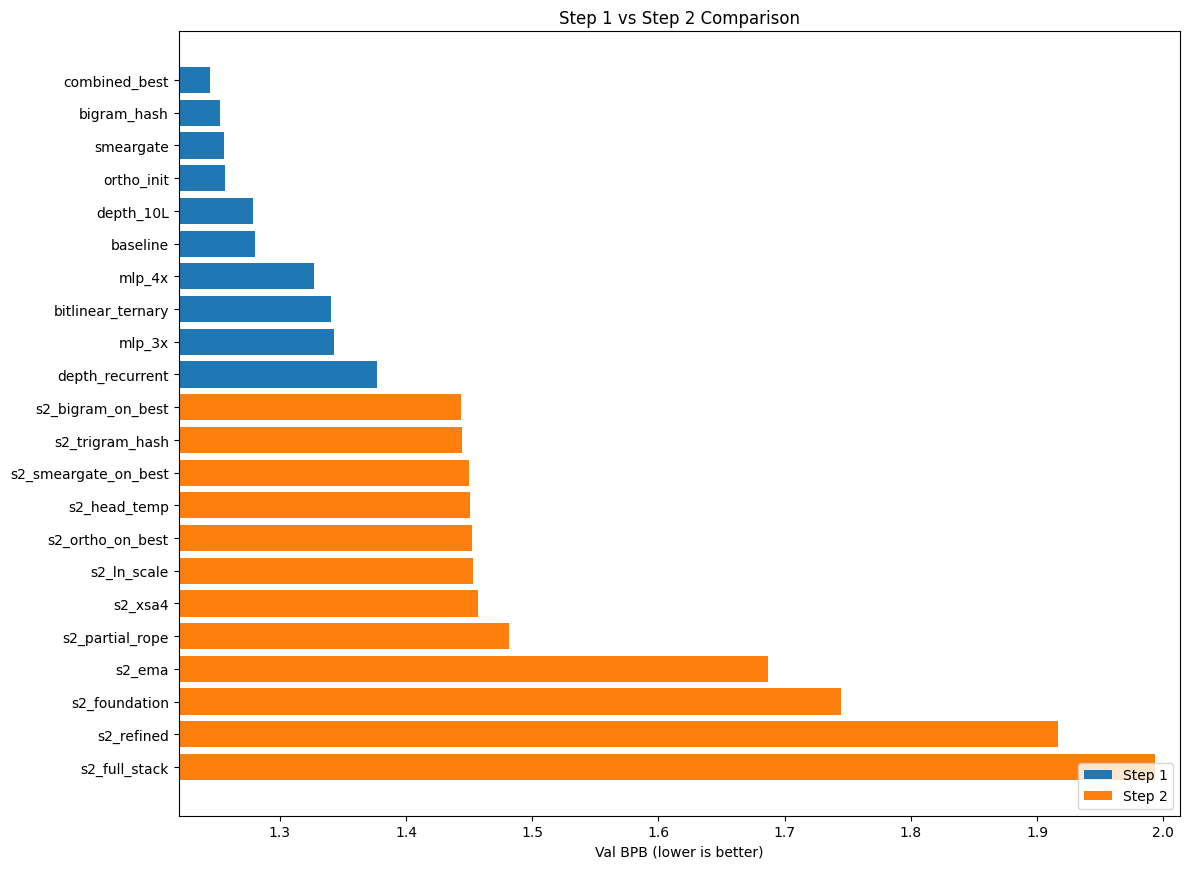


Overall best: combined_best (BPB=1.2448, Drive S1)


In [11]:
import json as jsonlib
import matplotlib.pyplot as plt

# Load results from Step 1, Step 2, and Google Drive
DIRS = {
    "experiments": "Step 1",
    "experiments_step2": "Step 2",
    "/content/drive/MyDrive/parameter-golf-experiments": "Drive S1",
    "/content/drive/MyDrive/parameter-golf-experiments-step2": "Drive S2",
}

results = {}
for base_dir, label in DIRS.items():
    if not os.path.exists(base_dir):
        continue
    for fname in sorted(globmod.glob(f"{base_dir}/*/result.json")):
        with open(fname) as f:
            r = jsonlib.load(f)
        r["_source"] = label
        results[r["experiment"]] = r

results = list(results.values())

if not results:
    print("No results found. Run experiments first!")
else:
    results.sort(key=lambda r: r.get("val_bpb", 999))

    print(f"{'#':<3} {'Experiment':<25} {'BPB':>8} {'Loss':>8} {'Source':>8}")
    print("-" * 55)
    for i, r in enumerate(results):
        print(f"{i+1:<3} {r['experiment']:<25} {r.get('val_bpb',0):>8.4f} {r.get('val_loss',0):>8.4f} {r.get('_source','?'):>8}")

    # Plot
    fig, ax = plt.subplots(1, 1, figsize=(12, max(6, len(results) * 0.4)))
    names = [r["experiment"] for r in results]
    bpbs = [r.get("val_bpb", 0) for r in results]
    colors = ["tab:orange" if "s2_" in r["experiment"] else "tab:blue" for r in results]

    ax.barh(names, bpbs, color=colors)
    ax.set_xlabel("Val BPB (lower is better)")
    ax.set_title("Step 1 vs Step 2 Comparison")
    ax.invert_yaxis()
    if bpbs:
        ax.set_xlim(min(bpbs) * 0.98, max(bpbs) * 1.01)
    ax.legend(
        handles=[
            plt.Rectangle((0,0),1,1, fc="tab:blue", label="Step 1"),
            plt.Rectangle((0,0),1,1, fc="tab:orange", label="Step 2"),
        ], loc="lower right",
    )
    plt.tight_layout()
    plt.show()

    best = results[0]
    print(f"\nOverall best: {best['experiment']} (BPB={best.get('val_bpb','?')}, {best.get('_source','?')})")

### Save to Google Drive

In [12]:
from google.colab import drive
import shutil

drive.mount("/content/drive")

DRIVE_DIR = "/content/drive/MyDrive/parameter-golf-experiments-step2"
os.makedirs(DRIVE_DIR, exist_ok=True)

copied = []
if os.path.exists("experiments_step2"):
    for exp_name in sorted(os.listdir("experiments_step2")):
        src = f"experiments_step2/{exp_name}"
        dst = f"{DRIVE_DIR}/{exp_name}"
        if os.path.isdir(src):
            if os.path.exists(dst):
                shutil.rmtree(dst)
            shutil.copytree(src, dst)
            copied.append(exp_name)

print(f"Saved to: {DRIVE_DIR}")
print(f"Step 2 experiments copied: {len(copied)}")
for name in copied:
    result_file = f"{DRIVE_DIR}/{name}/result.json"
    if os.path.exists(result_file):
        with open(result_file) as f:
            r = jsonlib.load(f)
        print(f"  {name}: BPB={r.get('val_bpb', '?')}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved to: /content/drive/MyDrive/parameter-golf-experiments-step2
Step 2 experiments copied: 0
